# Phase Axis Formatters & Locators

One-stop guide to format Matplotlib axes in multiples of π for phase/radian data using `PiFormatter`, `PiLocator`, and `setup_phase_axis`.


## What & Why
Phase data (e.g., wrapped interferometric phase) is naturally expressed in radians.
Displaying ticks as clean multiples/fractions of π improves readability over raw decimal radians.
This tutorial shows how to format axes in π units for clearer phase plots.


## Quick Start
3 steps: import, plot, apply π-based formatter/locator.


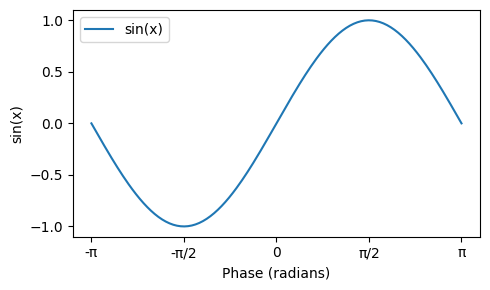

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from faninsar.plotting.formatters import PiFormatter, PiLocator, setup_phase_axis

x = np.linspace(-np.pi, np.pi, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, np.sin(x), label="sin(x)")

# Option A: manual control
ax.xaxis.set_major_locator(PiLocator(base=0.5))  # π/2
ax.xaxis.set_major_formatter(PiFormatter(denominator=4))

# Option B: convenience helper (uncomment to try)
# setup_phase_axis(ax.xaxis, base=0.5, denominator=4)

ax.set_xlabel("Phase (radians)")
ax.set_ylabel("sin(x)")
ax.legend()
fig.tight_layout()
plt.show()


Expected: x-axis ticks like −π, −π/2, 0, π/2, π.


## Core Concepts
- [PiFormatter](#faninsar.plotting.formatters.PiFormatter) converts radians into multiples of π; supports plain text and LaTeX mathtext.
- [PiLocator](#faninsar.plotting.formatters.PiLocator) places ticks at base×π intervals (e.g., 0.25 → π/4).
- [setup_phase_axis](#faninsar.plotting.formatters.setup_phase_axis) applies both to a given axis (e.g., `ax.xaxis` or `ax.yaxis`).


## Parameters & Options
PiFormatter
- `denominator` (int, default 4): max fraction denominator (e.g., 3π/4). Larger → finer fractions.
- `symbol` (str | None): override π symbol (e.g., `"pi"`). If `latex=True` and None → `\pi`.
- `use_unicode` (bool, default True): use `π` vs `pi` when `latex=False`.
- `latex` (bool, default False): render labels with mathtext (e.g., `$\frac{\pi}{2}$`).

PiLocator
- `base` (float, default 0.5): spacing in multiples of π; common values: 1.0 (π), 0.5 (π/2), 0.25 (π/4).


In [8]:
# Micro-examples for PiFormatter
from faninsar.plotting.formatters import PiFormatter

print("Default (π symbol):", PiFormatter()(np.pi/2))           # 'π/2'
print("ASCII symbol:", PiFormatter(symbol="pi")(np.pi))     # 'pi'
print("LaTeX:", PiFormatter(latex=True)(-np.pi))                 # '$-\pi$'
print("Finer fraction:", PiFormatter(denominator=8)(3*np.pi/8))  # '3π/8'


Default (π symbol): π/2
ASCII symbol: pi
LaTeX: $-\pi$
Finer fraction: 3π/8


## Extended Examples (3)
### 1) Y-axis as phase (LaTeX labels)


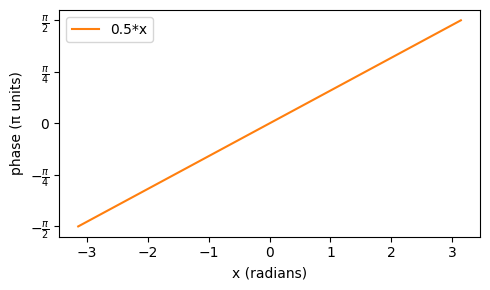

In [13]:
x = np.linspace(-np.pi, np.pi, 200)
y = 0.5 * x  # linear ramp in radians

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y, color="tab:orange", label="0.5*x")
setup_phase_axis(ax.yaxis, base=0.25, denominator=4, latex=True)
ax.set_xlabel("x (radians)")
ax.set_ylabel("phase (π units)")
ax.legend()
fig.tight_layout()
plt.show()

### 2) Custom symbol and fine fractions


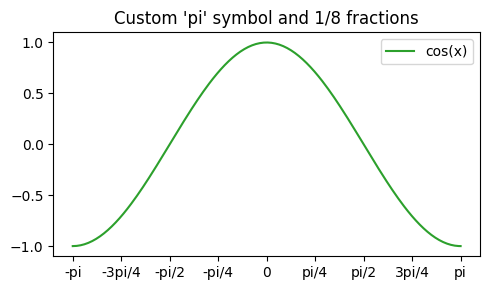

In [15]:
x = np.linspace(-np.pi, np.pi, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, np.cos(x), color="tab:green", label="cos(x)")
ax.xaxis.set_major_locator(PiLocator(base=0.25))   # π/4
ax.xaxis.set_major_formatter(PiFormatter(denominator=8, symbol="pi"))
ax.set_title("Custom 'pi' symbol and 1/8 fractions")
ax.legend()
fig.tight_layout(); plt.show()


### 3) Both axes as phase


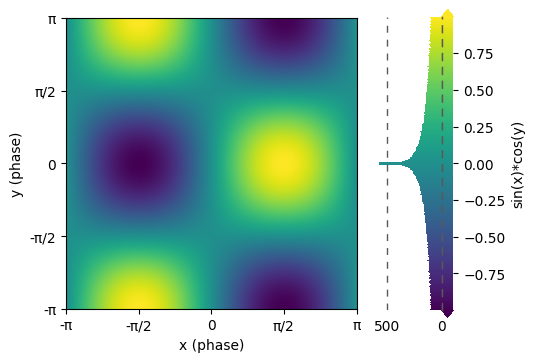

In [19]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.linspace(-np.pi, np.pi, 200)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin="lower")
setup_phase_axis(ax.xaxis, base=0.5, denominator=4, latex=False)
setup_phase_axis(ax.yaxis, base=0.5, denominator=4, latex=False)
ax.set_xlabel("x (phase)")
ax.set_ylabel("y (phase)")
fig.hist_colorbar(Z, im, ax=ax, extend="both", label="sin(x)*cos(y)")
plt.show()

## Best Practices
- Choose `base` to balance readability and density; `0.25` (π/4) is a good starting point.
- Use `latex=True` in publication-quality figures for better typography.
- Keep `denominator` modest (4–8) to avoid overly complex labels.
- Apply formatters to the correct axis object (`ax.xaxis` vs `ax.yaxis`).


## Troubleshooting & FAQs
- Labels show decimals like `1.1π` instead of fractions → increase `denominator`; decimals are used when a clean fraction is not close.
- Tiny values display as `0` → values with |x/π| < 1e-10 are treated as zero to reduce noise.
- Ticks not as expected → ensure axis limits include multiples of π and that the locator/formatter are set on the intended axis.


## API Cheat Sheet


In [12]:
from faninsar.plotting import PiFormatter, PiLocator, setup_phase_axis
import matplotlib.pyplot as plt

# X-axis: π/2 spacing, plain text
ax = plt.subplots(figsize=(4, 2))[1]
ax.xaxis.set_major_locator(PiLocator(base=0.5))
ax.xaxis.set_major_formatter(PiFormatter(denominator=4, latex=False))
plt.close()

# Y-axis: π/4 spacing, LaTeX labels
ax = plt.subplots(figsize=(4, 2))[1]
setup_phase_axis(ax.yaxis, base=0.25, denominator=8, latex=True)
plt.close()


## Further Reading
- Matplotlib TickLocators/Formatters: https://matplotlib.org/stable/api/ticker_api.html
- NumPy: https://numpy.org/doc/stable/
